In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [119]:
block_size = 5
def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 5]) torch.Size([182580])
torch.Size([22740, 5]) torch.Size([22740])
torch.Size([22826, 5]) torch.Size([22826])


In [8]:
n1

25626

In [9]:
C = torch.randn((27, 2))

In [10]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [11]:
W1 = torch.randn((6, 100))
b1 = torch.rand(100)

In [12]:
# use -1 to infer dimension
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [13]:
h

tensor([[ 0.9594, -0.4038, -0.7068,  ...,  0.1517,  0.6877,  0.4422],
        [ 0.6426,  0.7308, -0.2500,  ...,  0.2754,  0.6486,  0.7335],
        [-0.9869,  0.8721,  0.7956,  ...,  0.6581,  0.5462,  0.5935],
        ...,
        [-0.9995,  0.9956,  0.3759,  ...,  0.7039, -0.3282,  0.0428],
        [-0.9999,  0.9999,  0.5324,  ...,  0.8078,  0.9531, -0.8032],
        [-0.9803,  0.7647,  0.3764,  ...,  0.9895,  0.6117, -0.2798]])

In [14]:
(emb.view(-1, 6) @ W1 ).shape, b1.shape, h.shape

(torch.Size([228146, 100]), torch.Size([100]), torch.Size([228146, 100]))

In [15]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [16]:
logits = h @ W2 + b2

In [17]:
logits.shape

torch.Size([228146, 27])

In [18]:
counts = logits.exp()

In [19]:
prob = counts / counts.sum(1, keepdim=True)

In [20]:
prob.shape

torch.Size([228146, 27])

In [ ]:
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [149]:
g = torch.Generator().manual_seed(2147483647)
embdim = 5
C = torch.randn((27, embdim), generator=g)
dims = block_size * embdim
W1 = torch.randn((dims, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [150]:
sum(p.nelement() for p in parameters)

16062

In [151]:
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
lri = []
lossi = []
stepi = []

In [152]:
for i in range(500000):
    #construct a minibatch 
    ix = torch.randint(0, Xtr.shape[0], (32,))


    # forward
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, dims) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    # backward
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)
        
print(loss.item())

2.7226855754852295


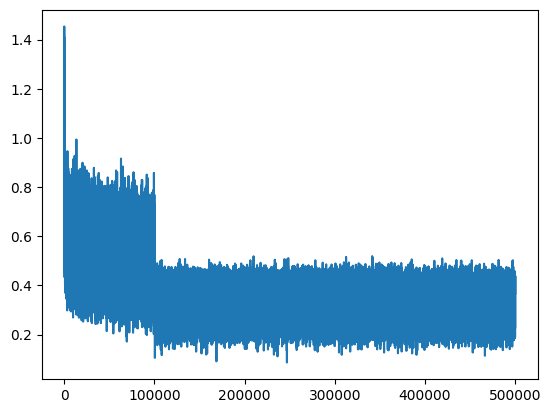

In [153]:
plt.plot(stepi, lossi)

In [154]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, dims) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1436, grad_fn=<NllLossBackward0>)

In [155]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, dims) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1726, grad_fn=<NllLossBackward0>)

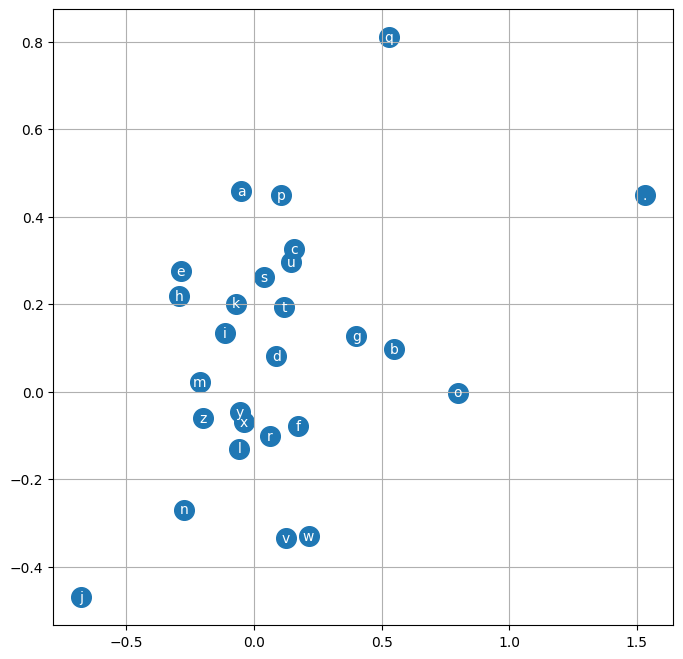

In [31]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
C[:,0].shape


torch.Size([27])

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khirgy.
kher.
cassanden.
jazonte.
deliah.
jareei.
nellara.
chaiivin.
leigh.
ham.
joce.
quint.
sulin.
alia.
bicw.
jero.
dearyni.
jaxeenissa.


In [1]:
[1,2,3][:1]


[1]